# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
# Import models you're considering


## Model Selection
Our oceanographic profiles have two dimensions (depth x size bin), where Biovolume values in neighboring depths and size bins are correlated. This suggests that the 2D pattern of Biovolume is of importance.
By visualizing these 2D patterns as heatmaps, we aim to classify Profiles using convolutional neural networks (CNN). 
- We start by testing a simple CNN and low-resolution heatmaps (with only 45 x 45 pixels)
- We aim to progress towards createing higher-resolution heatmaps with interpolation between data points which we aim to use for transfer learning.

## Feature Engineering

Beyond the baseline preprocessing, our feature engineering focused on preparing the UVP particle-biovolume profiles for convolution-based classification. First, all biovolume values were normalized on a per-profile basis to reduce the influence of varying absolute particle concentrations and highlight relative vertical distribution patterns. Each profile was then reshaped into a structured 40×17 depth–size matrix, effectively forming a 2D heatmap representation. This transformation converts the raw measurements into spatially coherent feature maps suitable for convolutional neural networks. We deliberately refrained from introducing aggregated or hand-crafted features, as CNNs are expected to extract relevant spatial and multiscale patterns directly from the heatmaps.

- adding labels
- adding squared transformation

In [3]:
# TODO : Function Declaration Cell

import matplotlib.pyplot as plt
import os
import numpy as np

heatmap_data = []

## --------------------------------------------------------- ##

def pad_heatmap(
    arr: np.ndarray,
    pad_top: int = 2,
    pad_bottom: int = 3,
    pad_left: int = 1,
    pad_right: int = 0,
    value: float = 0.0,
) -> np.ndarray:
    """
    Pad ein 2D-Array (Heatmap) mit Konstanten (default: 0).

    arr:       2D-Array (H, W)
    pad_top:   zusätzliche Zeilen oben
    pad_bottom:zusätzliche Zeilen unten
    pad_left:  zusätzliche Spalten links
    pad_right: zusätzliche Spalten rechts
    value:     Füllwert (Standard: 0.0)
    """
    return np.pad(
        arr,
        pad_width=((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=value,
    )

## --------------------------------------------------------- ##

def create_profile_heatmap(df, profile_id, size_cols, out_dir, pixels=45):
    """
    Save a square heatmap for a single profile as a PNG file.
    Only the heatmap is saved — no axes, labels, or surrounding whitespace.
    """
    # Profil filtern
    prof = df[df["Profile_id"] == profile_id].copy()
    if prof.empty:
        return  # nichts zu tun, falls Profil fehlt

    # nach Tiefe sortieren
    prof = prof.sort_values("depth_bin")

    # 2D-Array: depth_bins x size_classes (z.B. 40 x 17)
    heatmap_data = pad_heatmap(prof[size_cols].to_numpy())

    # quadratische Figur
    fig = plt.figure(figsize=(1, 1), dpi=pixels)   # 1x1 inch → pixels x pixels
    ax = fig.add_axes([0, 0, 1, 1])                # Achse füllt die gesamte Fläche

    # Heatmap zeichnen
    ax.imshow(heatmap_data, origin="upper", aspect="auto",interpolation="nearest",)

    # alles ausblenden
    ax.axis("off")

    # Ausgabeordner
    os.makedirs(out_dir, exist_ok=True)

    # Dateinamen aus Profile_id ableiten (problematische Zeichen ersetzen)
    safe_id = str(profile_id)
    for ch in ['/', '\\', ':', ';', ' ']:
        safe_id = safe_id.replace(ch, '_')

    filepath = os.path.join(out_dir, f"{safe_id}.png")

    # speichern – quadratisch, ohne Achsen
    fig.savefig(filepath, dpi=pixels)
    plt.close(fig)


## --------------------------------------------------------- ##

def save_all_profiles(df, size_cols, out_dir="../Data/heatmaps", pixels=45, max_profiles=None):
    """
    Ruft create_profile_heatmap() für viele Profile auf.
    - max_profiles = None  → alle Profile
    - max_profiles = 10    → nur die ersten 10 Profile
    """
    os.makedirs(out_dir, exist_ok=True)

    profile_ids = df["Profile_id"].unique()

    # Wenn max_profiles gesetzt ist, nur die ersten N
    if max_profiles is not None:
        profile_ids = profile_ids[:max_profiles]

    for pid in profile_ids:
        create_profile_heatmap(df, pid, size_cols, out_dir, pixels=pixels)

## --------------------------------------------------------- ##

def normalize_by_profile_global_max(df, group_col, columns):
    """
    Normalisiert die angegebenen Spalten so, dass:
    - pro Gruppe (group_col, z.B. 'Profile-ID') genau EIN globales Maximum
      über alle angegebenen Spalten und alle Zeilen gesucht wird
    - alle Werte der Gruppe durch dieses globale Maximum geteilt werden
    - 0 bleibt 0
    """

    # 1. Relevante Spalten extrahieren
    sub = df[columns]

    # 2. Pro Gruppe (Profile) das Spaltenmaximum bestimmen
    #    → ergibt für jede Zeile einer Gruppe dieselben Spaltenmaxima
    group_col_max = df.groupby(group_col)[columns].transform("max")

    # 3. Aus diesen Spaltenmaxima das globale Maximum pro Gruppe ableiten
    #    → für jede Zeile einer Gruppe derselbe Skalar
    profile_max = group_col_max.max(axis=1)

    # 4. Division durch 0 vermeiden (Profil komplett 0)
    denom = profile_max.replace(0, 1)

    # 5. Alles durch diesen Skalar teilen
    normalized = sub.div(denom, axis=0)

    # 6. Zurück ins Original-DataFrame schreiben
    df_norm = df.copy()
    df_norm[columns] = normalized

    return df_norm

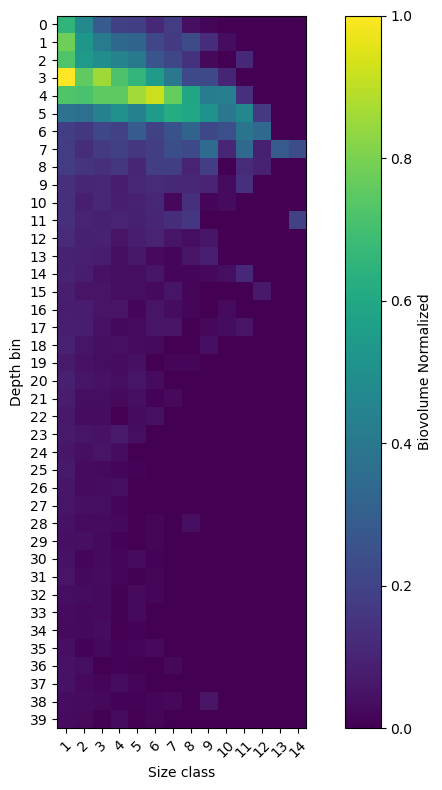

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.0,0.653745,0.470178,0.287066,0.188709,0.185985,0.113002,0.179574,0.041313,0.017411,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.0,0.780362,0.530190,0.415375,0.334251,0.323694,0.213776,0.168894,0.228241,0.126525,0.034254,0.000000,0.000000,0.000000,0.000000
4,0.0,0.725989,0.536002,0.490964,0.447350,0.403615,0.263119,0.212265,0.147485,0.022054,0.000000,0.112848,0.000000,0.000000,0.000000
5,0.0,1.000000,0.755412,0.859124,0.719881,0.659883,0.553178,0.400242,0.219777,0.220892,0.103590,0.000000,0.000000,0.000000,0.000000
6,0.0,0.724283,0.711253,0.750594,0.750754,0.860820,0.921165,0.763016,0.591890,0.425577,0.428972,0.139844,0.000000,0.000000,0.000000
7,0.0,0.379674,0.364668,0.437849,0.500825,0.439851,0.548332,0.618897,0.596689,0.508930,0.395237,0.467939,0.164274,0.000000,0.000000
8,0.0,0.182977,0.160569,0.213086,0.195146,0.286604,0.194086,0.251382,0.321281,0.215243,0.242631,0.383016,0.341691,0.000000,0.000000
9,0.0,0.178374,0.130879,0.168420,0.190184,0.157606,0.181640,0.239442,0.221491,0.351554,0.105616,0.343050,0.088982,0.281714,0.235100


In [4]:
# Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset

df = pd.read_pickle('../Data/Biovolume_per_size_class_and_depth_updated.pkl')

# Perform any feature engineering steps
# Example: df['new_feature'] = df['feature1'] + df['feature2']

import matplotlib.pyplot as plt
import numpy as np

# 1. Biovolume-Spalten auswählen
size_cols = [col for col in df.columns if col.startswith("Biovolume ")]
# Remove three of the largest size bins
size_cols = size_cols[:-3]

# Normalisierung – kann man machen wird grafisch aber schon automatisch vom plot erledigt
df = normalize_by_profile_global_max(df, "Profile_id", size_cols)
# display(df.head(40))

# 2. Ein Profil auswählen
pid = "0000a_WMO5906623_recovery_profiles"   # hier deine echte Profile_id einsetzen
df_prof = df[df["Profile_id"] == pid].copy()

# 3. Nach Tiefe sortieren (wichtig für "saubere" y-Achse)
df_prof = df_prof.sort_values("depth_bin")

# 4. 2D-Array für die Heatmap bauen: (n_depth_bins x n_size_classes)
heatmap_data = df_prof[size_cols].to_numpy()  # Shape ~ (40, 17)

# 5. Plotten
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(
    heatmap_data,
    aspect="equal",      # oder "equal" wenn du willst
    origin="upper"      # Tiefen von unten nach oben
)

# Achsen-Beschriftungen
ax.set_xlabel("Size class")
ax.set_ylabel("Depth bin")

# Optional: Ticks mit Spaltennamen
ax.set_xticks(np.arange(len(size_cols)))
ax.set_xticklabels(range(1, len(size_cols)+1), rotation=45)

ax.set_yticks(np.arange(len(df_prof["depth_bin"].unique())))
ax.set_yticklabels(sorted(df_prof["depth_bin"].unique()))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Biovolume Normalized")

plt.tight_layout()
plt.show()


pd.DataFrame(pad_heatmap(heatmap_data))

In [6]:
# TODO : Creation of Image Data Set

size_cols = [col for col in df.columns if col.startswith("Biovolume ")]
df = normalize_by_profile_global_max(df, "Profile_id", size_cols)

save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples", max_profiles=50) # save all profile heatmaps
save_all_profiles(df, size_cols[:-3])


## CNN workflow with small heatmaps & Cruise-based split

In [ ]:
# install if necessary:
#pip install imbalanced-learn pillow

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import pickle
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

class HeatmapCNNClassifier:
    def __init__(self, data_dir="../Data"):
        self.data_dir = Path(data_dir)
        self.heatmap_dir = self.data_dir / "heatmaps"
        self.train_test_file = self.data_dir / "Profile_id_to_train_test_cross_val.pkl"
        self.clusters_file = self.data_dir / "Profile_id_to_clusters.pkl"
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        
    def load_data_assignments(self):
        """Load data assignments from pickle files"""
        print("Loading data assignments...")
        
        # Load train/test and cross-validation assignments (DataFrame)
        with open(self.train_test_file, 'rb') as f:
            train_test_df = pickle.load(f)
        
        # Load cluster assignments (DataFrame)
        with open(self.clusters_file, 'rb') as f:
            clusters_df = pickle.load(f)
        
        print(f"Train/test DataFrame shape: {train_test_df.shape}")
        print(f"Clusters DataFrame shape: {clusters_df.shape}")
        print(f"Train/test columns: {train_test_df.columns.tolist()}")
        print(f"Clusters columns:  {clusters_df.columns.tolist()}")
        
        # Convert DataFrames to dictionaries for easier lookup
        # Assuming Profile_id is the key column
        self.train_test_cv = {}
        for _, row in train_test_df.iterrows():
            profile_id = row['Profile_id']
            # Create dictionary with remaining columns
            self.train_test_cv[profile_id] = {col: row[col] for col in train_test_df.columns if col != 'Profile_id'}
        
        self.clusters = {}
        for _, row in clusters_df.iterrows():
            profile_id = row['Profile_id']
            # Assuming there's a cluster column - let's find it
            cluster_cols = [col for col in clusters_df.columns if col != 'Profile_id']
            if len(cluster_cols) == 1:
                self.clusters[profile_id] = row[cluster_cols[0]]
            else:
                # If multiple columns, store as dictionary
                self.clusters[profile_id] = {col: row[col] for col in cluster_cols}
        
        print(f"Loaded assignments for {len(self.train_test_cv)} profiles")
        print(f"Loaded cluster assignments for {len(self.clusters)} profiles")
        
        # Show sample data structure
        sample_profile = list(self.train_test_cv.keys())[0]
        print(f"Sample train/test data for profile {sample_profile}:  {self.train_test_cv[sample_profile]}")
        print(f"Sample cluster data for profile {sample_profile}:  {self.clusters[sample_profile]}")
        
    def load_heatmaps(self):
        """Load heatmap images and create feature matrices"""
        print("Loading heatmap images...")
        
        # Get list of available heatmap files
        heatmap_files = list(self.heatmap_dir.glob("*.png"))
        print(f"Found {len(heatmap_files)} PNG files in {self.heatmap_dir}")
        
        if len(heatmap_files) == 0:
            raise FileNotFoundError(f"No PNG files found in {self.heatmap_dir}")
        
        # Extract profile IDs from filenames (remove .png extension)
        available_profile_ids = [f.stem for f in heatmap_files]
        
        # Debug: Show sample filenames and extracted profile IDs
        sample_files = heatmap_files[:5]
        sample_ids = [f.stem for f in sample_files]
        print(f"Sample filenames: {[f.name for f in sample_files]}")
        print(f"Sample extracted profile IDs: {sample_ids}")
        
        # Convert profile IDs to consistent format (strings)
        train_test_ids = set(str(k) for k in self.train_test_cv.keys())
        cluster_ids = set(str(k) for k in self.clusters.keys())
        filename_ids = set(str(id_) for id_ in available_profile_ids)
        
        print(f"Available profile IDs from filenames: {len(filename_ids)}")
        print(f"Profile IDs with train/test data: {len(train_test_ids)}")
        print(f"Profile IDs with cluster data:  {len(cluster_ids)}")
        
        # Find common profile IDs across all data sources
        common_with_train_test = filename_ids & train_test_ids
        common_with_clusters = filename_ids & cluster_ids
        common_all = filename_ids & train_test_ids & cluster_ids
        
        print(f"Files matching train/test IDs: {len(common_with_train_test)}")
        print(f"Files matching cluster IDs: {len(common_with_clusters)}")
        print(f"Files matching all data sources: {len(common_all)}")
        
        if len(common_all) == 0:
            print("\nDEBUGGING: No matching profile IDs found!")
            print("Sample IDs from each source:")
            print(f"Filenames: {list(filename_ids)[:5]}")
            print(f"Train/test:  {list(train_test_ids)[:5]}")
            print(f"Clusters: {list(cluster_ids)[:5]}")
            raise ValueError("No matching profile IDs found between files and metadata")
        
        common_ids = list(common_all)
        print(f"Found {len(common_ids)} profiles with complete data")
        
        # Load images and extract data
        X_data = []
        y_data = []
        profile_ids = []
        data_types = []
        cv_folds = []
        
        # Load a sample image to get dimensions
        sample_profile_id = common_ids[0]
        sample_img_path = self.heatmap_dir / f"{sample_profile_id}.png"
        sample_img = Image.open(sample_img_path)
        sample_array = np.array(sample_img)
        img_shape = sample_array.shape
        print(f"Image dimensions: {img_shape}")
        
        for profile_id_str in common_ids:
            # Convert string back to original type for dictionary lookup
            # Try both string and original type
            lookup_id = profile_id_str
            for original_id in self.train_test_cv.keys():
                if str(original_id) == profile_id_str:
                    lookup_id = original_id
                    break
            
            # Load image
            img_path = self.heatmap_dir / f"{profile_id_str}.png"
            img = Image.open(img_path)
            img_array = np.array(img)
            
            # Normalize pixel values to [0, 1]
            if img_array.dtype == np.uint8:
                img_array = img_array.astype(np.float32) / 255.0
            
            X_data.append(img_array)
            
            # Extract cluster assignment
            cluster_data = self.clusters[lookup_id]
            if isinstance(cluster_data, dict):
                # If cluster data is a dictionary, assume first value is the cluster
                y_data.append(list(cluster_data.values())[0])
            else:
                y_data.append(cluster_data)
            
            profile_ids.append(profile_id_str)
            data_types.append(self.train_test_cv[lookup_id]['data_type'])
            cv_folds.append(self.train_test_cv[lookup_id]['CV_fold'])
        
        self.X_data = np.array(X_data)
        self.y_data = np.array(y_data)
        self.profile_ids = np.array(profile_ids)
        self.data_types = np.array(data_types)
        self.cv_folds = np.array(cv_folds)
        
        print(f"Loaded {len(self.X_data)} heatmaps with shape {self.X_data.shape}")
        print(f"Unique clusters found: {np.unique(self.y_data)}")
        print(f"Data types found: {np.unique(self.data_types)}")
        print(f"CV folds found: {np.unique(self.cv_folds)}")
        
    def split_train_test(self):
        """Split data into train and test sets based on pre-defined assignments"""
        print("Splitting data into train and test sets...")
        
        train_mask = self.data_types == 'train'
        test_mask = self.data_types == 'test'
        
        self.X_train = self.X_data[train_mask]
        self.y_train = self.y_data[train_mask]
        self.train_profile_ids = self.profile_ids[train_mask]
        self.train_cv_folds = self.cv_folds[train_mask]
        
        self.X_test = self.X_data[test_mask]
        self.y_test = self.y_data[test_mask]
        self.test_profile_ids = self.profile_ids[test_mask]
        
        print(f"Training set:  {len(self.X_train)} samples")
        print(f"Test set: {len(self.X_test)} samples")
        
        # Encode labels
        self.y_train_encoded = self.label_encoder.fit_transform(self.y_train)
        self.y_test_encoded = self.label_encoder.transform(self.y_test)
        self.n_classes = len(self.label_encoder.classes_)
        
        print(f"Number of classes: {self.n_classes}")
        print(f"Classes: {self.label_encoder.classes_}")
        
    def check_class_balance(self):
        """Check class balance and display distribution"""
        print("\nClass distribution in training set:")
        train_counts = Counter(self.y_train)
        total_train = len(self.y_train)
        
        for cluster, count in sorted(train_counts.items()):
            percentage = (count / total_train) * 100
            print(f"Cluster {cluster}: {count} samples ({percentage:.1f}%)")
        
        # Check if balancing is needed
        min_count = min(train_counts.values())
        max_count = max(train_counts.values())
        imbalance_ratio = max_count / min_count
        
        print(f"\nImbalance ratio: {imbalance_ratio:.2f}")
        
        if imbalance_ratio > 2.0:
            print("Classes are imbalanced.  Applying resampling...")
            return True
        else:
            print("Classes are reasonably balanced.")
            return False
            
    def balance_classes_per_fold(self):
        """Apply balancing within each CV fold separately"""
        print("Balancing classes per fold using SMOTETomek (SMOTE + Tomek links)...")
        
        unique_folds = np.unique(self.train_cv_folds)
        print(f"Processing {len(unique_folds)} folds:  {unique_folds}")
        
        # Store balanced data for each fold
        self.fold_balanced_data = {}
        
        for fold in unique_folds:
            print(f"\nBalancing fold:  {fold}")
            
            # Get training data for this fold (all other folds)
            val_mask = self.train_cv_folds == fold
            train_mask = ~val_mask
            
            X_train_fold = self.X_train[train_mask]
            y_train_fold = self.y_train_encoded[train_mask]
            
            print(f"Original fold {fold} training size: {len(X_train_fold)}")
            
            # Check if balancing is needed for this fold
            fold_counts = Counter(y_train_fold)
            min_count = min(fold_counts.values())
            max_count = max(fold_counts.values())
            
            if max_count / min_count > 1.5:  # Apply balancing if imbalanced
                # Reshape data for resampling (flatten images)
                X_train_fold_flat = X_train_fold.reshape(len(X_train_fold), -1)
                
                # Apply SMOTETomek
                smote_tomek = SMOTETomek(
                    smote=SMOTE(random_state=42, k_neighbors=min(3, min_count-1)),
                    tomek=TomekLinks(),
                    random_state=42
                )
                
                X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train_fold_flat, y_train_fold)
                
                # Reshape back to image format
                X_train_balanced = X_train_balanced.reshape((-1,) + X_train_fold.shape[1:])
                
                print(f"Balanced fold {fold} training size: {len(X_train_balanced)}")
                
                # Show distribution after balancing
                balanced_counts = Counter(y_train_balanced)
                for cluster_idx, count in sorted(balanced_counts.items()):
                    cluster_name = self.label_encoder.classes_[cluster_idx]
                    print(f"  Cluster {cluster_name}: {count} samples")
                    
            else:
                print(f"Fold {fold} is already balanced, no resampling needed")
                X_train_balanced = X_train_fold
                y_train_balanced = y_train_fold
            
            # Store balanced data for this fold
            self.fold_balanced_data[fold] = {
                'X_train': X_train_balanced,
                'y_train': y_train_balanced,
                'X_val': self.X_train[val_mask],
                'y_val': self.y_train_encoded[val_mask]
            }
            
    def scale_data(self):
        """Scale the heatmap pixel data"""
        print("Scaling heatmap pixel data...")
        
        # Scale original training data for test set evaluation
        original_shape = self.X_train.shape
        X_train_flat = self.X_train.reshape(len(self.X_train), -1)
        X_test_flat = self.X_test.reshape(len(self.X_test), -1)
        
        # Fit scaler on original training data
        X_train_scaled = self.scaler.fit_transform(X_train_flat)
        X_test_scaled = self.scaler.transform(X_test_flat)
        
        # Reshape back to image format
        self.X_train_scaled = X_train_scaled.reshape(original_shape)
        self.X_test_scaled = X_test_scaled.reshape(self.X_test.shape)
        
        print(f"Scaled training data shape: {self.X_train_scaled.shape}")
        print(f"Scaled test data shape: {self.X_test_scaled.shape}")
        
        # Scale balanced data for each fold
        if hasattr(self, 'fold_balanced_data'):
            print("Scaling balanced fold data...")
            for fold in self.fold_balanced_data.keys():
                fold_data = self.fold_balanced_data[fold]
                
                # Scale training data for this fold
                X_train_fold_flat = fold_data['X_train'].reshape(len(fold_data['X_train']), -1)
                X_val_fold_flat = fold_data['X_val'].reshape(len(fold_data['X_val']), -1)
                
                # Use same scaler fitted on original training data
                X_train_fold_scaled = self.scaler.transform(X_train_fold_flat)
                X_val_fold_scaled = self.scaler.transform(X_val_fold_flat)
                
                # Reshape back to image format
                self.fold_balanced_data[fold]['X_train_scaled'] = X_train_fold_scaled.reshape((-1,) + fold_data['X_train'].shape[1:])
                self.fold_balanced_data[fold]['X_val_scaled'] = X_val_fold_scaled.reshape((-1,) + fold_data['X_val'].shape[1:])
        
    def create_cnn_model(self, input_shape):
        """Create CNN model architecture"""
        print(f"Creating CNN model for input shape: {input_shape}")
        
        model = Sequential([
            # First convolutional block
            Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
            BatchNormalization(),
            Conv2D(32, (3, 3), activation='relu', padding='same'),
            MaxPooling2D((2, 2)),
            Dropout(0.25),
            
            # Second convolutional block
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            MaxPooling2D((2, 2)),
            Dropout(0.25),
            
            # Third convolutional block
            Conv2D(128, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(128, (3, 3), activation='relu', padding='same'),
            MaxPooling2D((2, 2)),
            Dropout(0.25),
            
            # Fully connected layers
            Flatten(),
            Dense(512, activation='relu'),
            BatchNormalization(),
            Dropout(0.5),
            Dense(256, activation='relu'),
            Dropout(0.5),
            Dense(self.n_classes, activation='softmax')
        ])
        
        return model
        
    def compile_model(self, model):
        """Compile the CNN model"""
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model
        
    def cross_validate(self):
        """Perform cross-validation using pre-defined folds with balanced data"""
        print("Starting cross-validation with balanced data...")
        
        if not hasattr(self, 'fold_balanced_data'):
            print("No balanced fold data found. Using original data.")
            self.cross_validate_original()
            return
        
        unique_folds = list(self.fold_balanced_data.keys())
        print(f"Cross-validation folds: {unique_folds}")
        
        cv_results = {
            'balanced_accuracy': [],
            'macro_f1': [],
            'fold_predictions': [],
            'fold_true_labels': []
        }
        
        for fold in unique_folds: 
            print(f"\nProcessing fold: {fold}")
            
            # Get balanced data for this fold
            fold_data = self.fold_balanced_data[fold]
            X_train_fold = fold_data['X_train_scaled']
            y_train_fold = fold_data['y_train']
            X_val_fold = fold_data['X_val_scaled']
            y_val_fold = fold_data['y_val']
            
            print(f"Fold {fold} - Train: {len(X_train_fold)}, Val: {len(X_val_fold)}")
            
            # Convert to categorical
            y_train_fold_cat = to_categorical(y_train_fold, self.n_classes)
            y_val_fold_cat = to_categorical(y_val_fold, self.n_classes)
            
            # Create and compile model
            model = self.create_cnn_model(X_train_fold.shape[1:])
            model = self.compile_model(model)
            
            # Set up callbacks
            early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
            reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
            
            # Train model
            history = model.fit(
                X_train_fold, y_train_fold_cat,
                validation_data=(X_val_fold, y_val_fold_cat),
                epochs=100,
                batch_size=32,
                callbacks=[early_stopping, reduce_lr],
                verbose=0
            )
            
            # Make predictions
            y_pred_proba = model.predict(X_val_fold, verbose=0)
            y_pred = np.argmax(y_pred_proba, axis=1)
            
            # Calculate metrics
            bal_acc = balanced_accuracy_score(y_val_fold, y_pred)
            macro_f1 = f1_score(y_val_fold, y_pred, average='macro')
            
            cv_results['balanced_accuracy'].append(bal_acc)
            cv_results['macro_f1'].append(macro_f1)
            cv_results['fold_predictions'].extend(y_pred)
            cv_results['fold_true_labels'].extend(y_val_fold)
            
            print(f"Fold {fold} - Balanced Accuracy: {bal_acc:.4f}, Macro F1: {macro_f1:.4f}")
            
        self.cv_results = cv_results
        self.print_cv_results()
        
    def cross_validate_original(self):
        """Perform cross-validation using original (unbalanced) data"""
        print("Performing cross-validation with original data...")
        
        unique_folds = np.unique(self.train_cv_folds)
        print(f"Cross-validation folds:  {unique_folds}")
        
        cv_results = {
            'balanced_accuracy': [],
            'macro_f1': [],
            'fold_predictions': [],
            'fold_true_labels': []
        }
        
        for fold in unique_folds:
            print(f"\nProcessing fold: {fold}")
            
            # Split data for this fold
            val_mask = self.train_cv_folds == fold
            train_mask = ~val_mask
            
            X_train_fold = self.X_train_scaled[train_mask]
            y_train_fold = self.y_train_encoded[train_mask]
            X_val_fold = self.X_train_scaled[val_mask]
            y_val_fold = self.y_train_encoded[val_mask]
            
            print(f"Fold {fold} - Train: {len(X_train_fold)}, Val: {len(X_val_fold)}")
            
            # Convert to categorical
            y_train_fold_cat = to_categorical(y_train_fold, self.n_classes)
            y_val_fold_cat = to_categorical(y_val_fold, self.n_classes)
            
            # Create and compile model
            model = self.create_cnn_model(X_train_fold.shape[1:])
            model = self.compile_model(model)
            
            # Set up callbacks
            early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
            reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
            
            # Train model
            history = model.fit(
                X_train_fold, y_train_fold_cat,
                validation_data=(X_val_fold, y_val_fold_cat),
                epochs=100,
                batch_size=32,
                callbacks=[early_stopping, reduce_lr],
                verbose=0
            )
            
            # Make predictions
            y_pred_proba = model.predict(X_val_fold, verbose=0)
            y_pred = np.argmax(y_pred_proba, axis=1)
            
            # Calculate metrics
            bal_acc = balanced_accuracy_score(y_val_fold, y_pred)
            macro_f1 = f1_score(y_val_fold, y_pred, average='macro')
            
            cv_results['balanced_accuracy'].append(bal_acc)
            cv_results['macro_f1'].append(macro_f1)
            cv_results['fold_predictions'].extend(y_pred)
            cv_results['fold_true_labels'].extend(y_val_fold)
            
            print(f"Fold {fold} - Balanced Accuracy: {bal_acc:.4f}, Macro F1: {macro_f1:.4f}")
            
        self.cv_results = cv_results
        self.print_cv_results()
        
    def print_cv_results(self):
        """Print cross-validation results"""
        bal_acc_mean = np.mean(self.cv_results['balanced_accuracy'])
        bal_acc_std = np.std(self.cv_results['balanced_accuracy'])
        f1_mean = np.mean(self.cv_results['macro_f1'])
        f1_std = np.std(self.cv_results['macro_f1'])
        
        print(f"\nCross-Validation Results:")
        print(f"Balanced Accuracy: {bal_acc_mean:.4f} ± {bal_acc_std:.4f}")
        print(f"Macro F1 Score: {f1_mean:.4f} ± {f1_std:.4f}")
        
 
    def run_full_pipeline(self):
        """Run the complete pipeline"""
        print("Starting Heatmap CNN Classification Pipeline")
        print("=" * 50)
        
        # Step 1: Load data
        self.load_data_assignments()
        self.load_heatmaps()
        
        # Step 2: Split train/test
        self.split_train_test()
        
        # Step 3: Check class balance
        needs_balancing = self.check_class_balance()
        
        # Step 4: Balance classes if needed (per fold)
        if needs_balancing:
            self.balance_classes_per_fold()
        
        # Step 5: Scale data
        self.scale_data()
        
        # Step 6: Cross-validation
        self.cross_validate()
                
        print("\nPipeline completed successfully!")

# Run the pipeline
if __name__ == "__main__":
    # Initialize and run the classifier
    classifier = HeatmapCNNClassifier(data_dir="../Data")
    classifier.run_full_pipeline()

Starting Heatmap CNN Classification Pipeline
Loading data assignments...
Train/test DataFrame shape: (5613, 3)
Clusters DataFrame shape: (5613, 2)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster']
Loaded assignments for 5613 profiles
Loaded cluster assignments for 5613 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  8
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO5906623_recovery_profiles', '0003a_WMO6904139_recovery', '0004a_WMO6903096']
Available profile IDs from filenames: 5619
Profile IDs with train/test data: 5613
Pr

## Hyperparameter Tuning

[Discuss any hyperparameter tuning methods you've applied, such as Grid Search or Random Search, and the rationale behind them.]


In [214]:
# Implement hyperparameter tuning
# Example using GridSearchCV with a DecisionTreeClassifier
# param_grid = {'max_depth': [2, 4, 6, 8]}
# grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
# grid_search.fit(X_train, y_train)


## Implementation

[Implement the final model(s) you've selected based on the above steps.]


In [215]:
# Implement the final model(s)
# Example: model = YourChosenModel(best_hyperparameters)
# model.fit(X_train, y_train)


## Evaluation Metrics

[Clearly specify which metrics you'll use to evaluate the model performance, and why you've chosen these metrics.]


In [216]:
# Evaluate the model using your chosen metrics
# Example for classification
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))

# Example for regression
# mse = mean_squared_error(y_test, y_pred)

# Your evaluation code here


## Comparative Analysis

[Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.]


In [217]:
# Comparative Analysis code (if applicable)
# Example: comparing accuracy of the baseline model and the new model
# print(f"Baseline Model Accuracy: {baseline_accuracy}, New Model Accuracy: {new_model_accuracy}")
